# Build the codon variants
Analyze the codon mutations in the variants and build a codon-variant table.

First, import Python modules:

In [1]:
import re
import yaml
import tempfile
import itertools

import pandas as pd
import altair as alt
import matplotlib.pyplot as plt

import Bio.SeqIO
import dms_variants.codonvarianttable

In [2]:
# allow more rows for Altair
_ = alt.data_transformers.disable_max_rows()

In [3]:
# Set path prefix to "../" if running locally and "" if running with Snakemake
path_prefix = ""

Read configuration:

In [4]:
# If you are running notebook interactively rather than in pipeline that handles
# working directories, you may have to first `os.chdir` to appropriate directory.

with open(path_prefix + "config.yaml") as f:
    config = yaml.safe_load(f)

Now read the variants for our gene of interest (primary target) and make sure there are no overlapping barcodes with the neutralization standard:

In [5]:
nt_variants = path_prefix + "results/variants/nt_variants.csv"
print(f"Reading gene variants from {nt_variants}")
gene_variants = pd.read_csv(nt_variants, na_filter=False)

Reading gene variants from results/variants/nt_variants.csv


Now initialize a [CodonVariantTable](https://jbloomlab.github.io/dms_variants/dms_variants.codonvarianttable.html), which requires the wildtype gene sequence and the list of nucleotide mutations in each barcoded gene variant.
We add the variants of our gene under `gene` as the `primary_target`, and the neutralization standards as a secondary target.
Note that we use the `allowgaps` option as gaps are being allowed:

In [6]:
# Get the gene sequence for each library design (they should be the same)
design_df = pd.read_csv(path_prefix + config['runs'])[['library', 'design']]
design_df.head()

geneseqs = {}
for design in design_df.design.unique():
    geneseqs[design] = str(Bio.SeqIO.read(path_prefix + f"results/gene_sequence/{design}_codon.fasta", "fasta").seq)
 

# Make sure all gene sequences are the same length
assert len({len(seq) for seq in geneseqs.values()}) == 1

# Assign the first sequence to the variable `geneseq` for use in the rest of the notebook
geneseq = next(iter(geneseqs.values()))

assert len(geneseq) % 3 == 0
print(f"Read gene of length {len(geneseq)} nucleotides as primary target")

Read gene of length 3450 nucleotides as primary target


In [7]:
# make a data frame with the gene variants and neutralization standard
variants_df = gene_variants.assign(target="gene")
 


# now build the CodonVariantTables
with tempfile.NamedTemporaryFile(mode="w") as f:
    variants_df.to_csv(f)
    f.flush()
    variants = dms_variants.codonvarianttable.CodonVariantTable(
        barcode_variant_file=f.name,
        geneseq=geneseq,
        allowgaps=True,
        primary_target="gene",
    )

## Number of mutations per variant

Plot some basic stats on the number of mutations per variant:

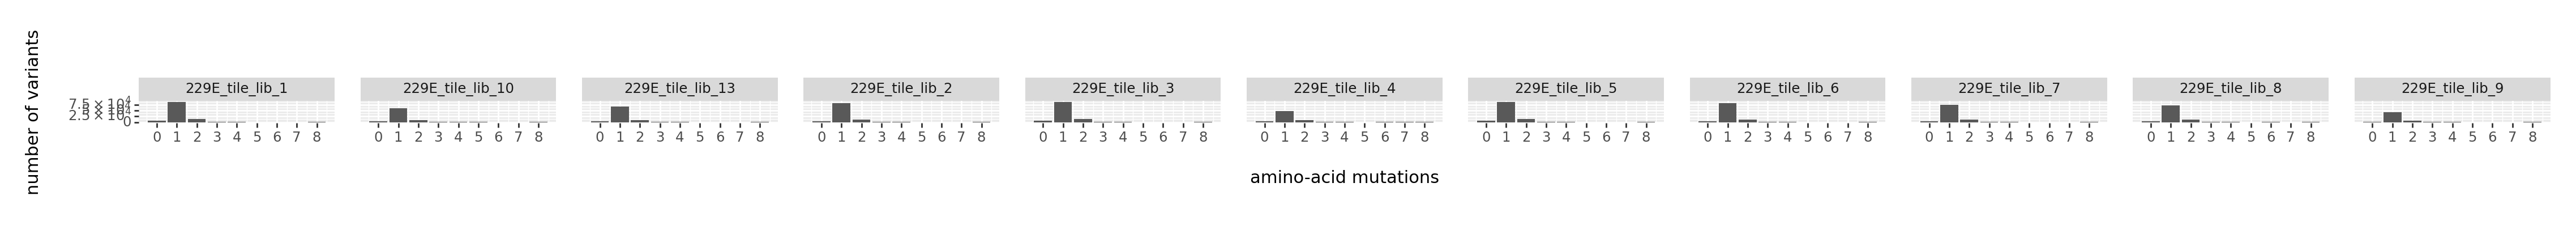

In [8]:
# distribution of amino-acid mutations per variant
p = variants.plotNumMutsHistogram(
    mut_type="aa",
    max_muts=8,
    widthscale=1.3,
    heightscale=1,
    libraries=variants.libraries,
    samples=None,
)
fig = p.draw(show=True)

What percentage of the GenScript mutations are single mutations? More than 75% of mutations should be single codon mutations.

In [9]:
# Get the data used to plot the above histogram
df, _, _ = variants._getPlotData(
    libraries=variants.libraries,
    samples=None,
    min_support=1,
    primary_target_only=True,
    sample_rename=None,
)

# Group by library, sample, and number of amino-acid substitutions
df = (
    df.groupby(["library", "sample", "n_aa_substitutions"], observed=True)
    .aggregate({"count": "sum"})
    .reset_index()
)

# Calculate the total count for each library
df['total_count'] = df.groupby('library')['count'].transform('sum')

# Calculate the percentage
df['percentage'] = (df['count'] / df['total_count']) * 100

# Drop the total count column
df = df.drop(columns='total_count')

# Get the percentage of variants with one amino-acid substitutions for each library
df = df[df['n_aa_substitutions'] == 1]

print(df.reset_index(drop=True))

             library             sample  n_aa_substitutions  count  percentage
0    229E_tile_lib_1  barcoded variants                   1  87568   82.037061
1   229E_tile_lib_10  barcoded variants                   1  58579   82.634823
2   229E_tile_lib_13  barcoded variants                   1  67771   82.835456
3    229E_tile_lib_2  barcoded variants                   1  80960   82.168702
4    229E_tile_lib_3  barcoded variants                   1  86362   81.795365
5    229E_tile_lib_4  barcoded variants                   1  48127   77.705659
6    229E_tile_lib_5  barcoded variants                   1  86775   81.475048
7    229E_tile_lib_6  barcoded variants                   1  80800   84.050222
8    229E_tile_lib_7  barcoded variants                   1  74648   83.352502
9    229E_tile_lib_8  barcoded variants                   1  71075   83.138379
10   229E_tile_lib_9  barcoded variants                   1  42217   83.292887


/tmp/ipykernel_42953/4247673798.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


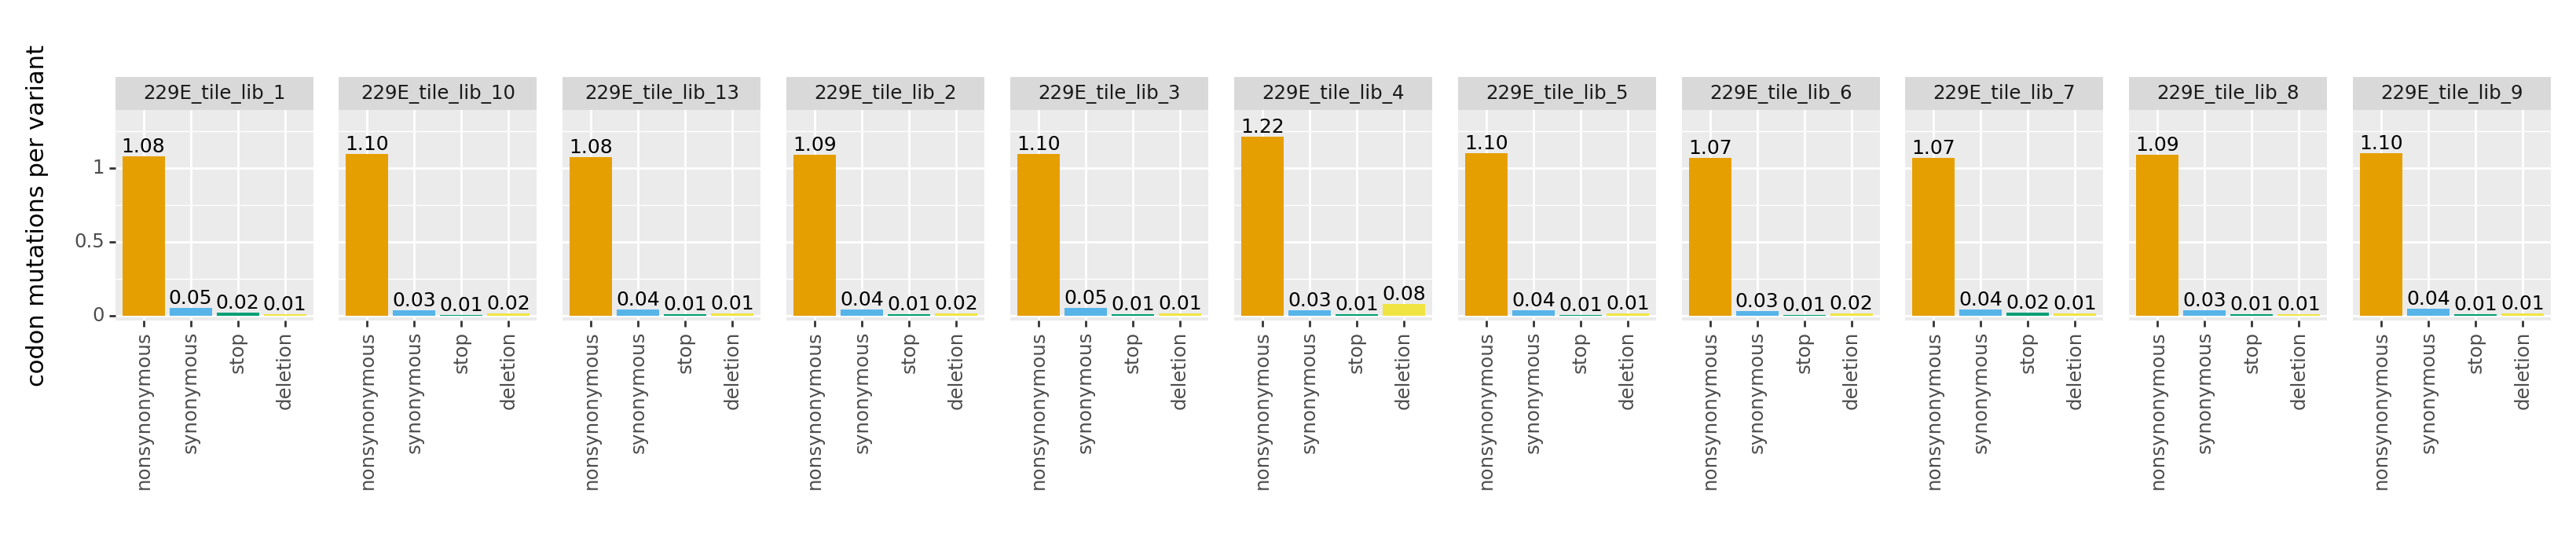

In [10]:
# average mutations per variant
p = variants.plotNumCodonMutsByType(
    variant_type="all",
    samples=None,
    libraries=variants.libraries,
    widthscale=1,
    heightscale=1.5,
    ylabel="codon mutations per variant",
)
fig = p.draw(show=True)

## Counts of different types of mutations in the libraries
Read the designed mutations for the library, combine with site numbering file, and remove mutations that correspond to what is already wildtype in parental sequence:

In [11]:
portseqs = {}
for design in design_df.design.unique():
    portseqs[design] = str(Bio.SeqIO.read(path_prefix + f"results/gene_sequence/{design}_protein.fasta", "fasta").seq)
 

# Make sure all gene sequences are the same length
assert len({len(seq) for seq in portseqs.values()}) == 1

# Assign the first sequence to the variable `geneseq` for use in the rest of the notebook
portseq = next(iter(portseqs.values()))

In [12]:
# read designed mutations
designed_muts_site_col = config["mutation_design_classification"]["site_col"]
designed_mutations = pd.read_csv(
    path_prefix + config["mutation_design_classification"]["csv"]
).rename(columns={"amino_acid": "mutant_aa"})[
    [designed_muts_site_col, "mutant_aa", "mutation_type"]
]

# list of designed mutation types in order of abundance
designed_mutation_types = (
    designed_mutations.groupby("mutation_type")
    .size()
    .sort_values(ascending=False)
    .index.tolist()
)

# read reference site numbering
site_numbering_map = pd.read_csv(path_prefix + config["site_numbering_map"])
assert site_numbering_map[["sequential_site", "reference_site"]].notnull().all().all()

# read wildtype protein
refprot = portseq
assert len(refprot) >= site_numbering_map["sequential_site"].max()
assert site_numbering_map["sequential_site"].min() >= 1

# add reference site numbering and remove wildtype to wildtype mutations
designed_mutations = (
    designed_mutations.merge(
        site_numbering_map[["sequential_site", "reference_site"]],
        on=designed_muts_site_col,
        validate="many_to_one",
    )
    .rename(columns={"mutation_type": "designed_mutation_type"})
    .assign(wildtype=lambda x: x["sequential_site"].map(lambda r: refprot[r - 1]))
    .query("wildtype != mutant_aa")
    .assign(
        sequential_mutation=lambda x: x["wildtype"]
        + x["sequential_site"].astype(str)
        + x["mutant_aa"],
        reference_mutation=lambda x: x["wildtype"]
        + x["reference_site"].astype(str)
        + x["mutant_aa"],
    )[
        [
            "sequential_site",
            "sequential_mutation",
            "reference_site",
            "reference_mutation",
            "designed_mutation_type",
        ]
    ]
)

## Mutation frequencies along the gene
Average frequency of mutations across all variants at each site:

In [13]:
# frequencies of mutations at each site
site_freqs = (
    variants.mutCounts(
        variant_type="all",
        mut_type="aa",
        samples=None,
        libraries=variants.libraries,
    )
    .query("count > 0")
    .rename(columns={"site": "sequential_site"})
    .merge(
        site_numbering_map,
        how="left",
        on="sequential_site",
        validate="many_to_one",
    )
    .assign(
        wildtype=lambda x: x["mutation"].str[0],
        mutant=lambda x: x["mutation"].str[-1],
        reference_site=lambda x: (
            x["reference_site"]
            if all(x["reference_site"] == x["reference_site"].astype(str))
            else x["reference_site"].astype("Int64")
        ),
        # remove categorical assignments to fix plotting issues
        library=lambda x: x["library"].tolist(),
    )
    .assign(mutant=lambda x: x["mutant"] + "=" + x["count"].astype(str))
    .sort_values("count", ascending=False)
    .groupby(
        ["library", "sequential_site", "reference_site", "wildtype"],
        observed=True,
        as_index=False,
    )
    .aggregate(
        count=pd.NamedAgg("count", "sum"),
        mutants=pd.NamedAgg("mutant", ", ".join),
    )
    .merge(
        variants.n_variants_df(
            samples=None, libraries=variants.libraries, primary_target_only=True
        )
        .rename(columns={"count": "n_variants"})
        .drop(columns="sample")
    )
    .assign(percent=lambda x: 100 * x["count"] / x["n_variants"])
    .drop(columns="n_variants")
)

In [14]:
# make chart
zoom_brush = alt.selection_interval(
    encodings=["x"],
    mark=alt.BrushConfig(stroke="black", strokeWidth=2),
)

zoom_bar = (
    alt.Chart(site_freqs[["sequential_site", "reference_site"]].drop_duplicates())
    .mark_rect(color="lightgrey")
    .encode(
        x=alt.X(
            "reference_site",
            title=None,
            scale=alt.Scale(nice=False, zero=False),
            sort=alt.SortField("sequential_site"),
            axis=alt.Axis(labelOverlap=True),
        )
    )
    .add_params(zoom_brush)
    .properties(width=550, height=15, title="site zoom bar")
)

site_freqs_base = (
    alt.Chart()
    .encode(
        x=alt.X(
            "reference_site",
            scale=alt.Scale(nice=False, zero=False),
            sort=alt.SortField("sequential_site"),
            axis=alt.Axis(labelOverlap=True),
        ),
        y=alt.Y("percent", title="% variants with mutation"),
        tooltip=[
            (
                alt.Tooltip(c, format=".3g")
                if c in {"percent", "count", "n_variants"}
                else c
            )
            for c in site_freqs.columns
        ],
    )
    .properties(height=125, width=550)
)

site_freqs_chart = (
    alt.layer(
        site_freqs_base.mark_point(filled=True),
        site_freqs_base.mark_line(size=0.5),
        data=site_freqs,
    )
    .facet(facet=alt.Facet("library", title=None), columns=1)
    .add_params(zoom_brush)
    .transform_filter(zoom_brush)
)

site_freqs_zoom_chart = (zoom_bar & site_freqs_chart).configure_axis(grid=False)

site_freqs_zoom_chart.save(path_prefix + "results/site_coverage_chart.html")
site_freqs_zoom_chart

alt.VConcatChart(...)

## How many variants have each mutation?
We categorize mutations by the design categories into which they fall.
Only include mutations that are either observed or designed:

In [15]:
# get ranked counts of each mutation designed in libraries
# first get counts
mut_counts_designed = (
    variants.mutCounts(
        variant_type="all",
        mut_type="aa",
        samples=None,
        libraries=variants.libraries,
    )
    .rename(columns={"mutation": "sequential_mutation", "site": "sequential_site"})
    .merge(
        designed_mutations,
        how="outer",
        on=["sequential_mutation", "sequential_site"],
        validate="many_to_many",
    )
    .drop(columns=["reference_site", "sample"])
    .assign(
        designed_mutation_type=lambda x: x["designed_mutation_type"].fillna(
            "unintended mutation"
        ),
        # remove categorical assignments to fix plotting issues
        library=lambda x: x["library"].tolist(),
        mutation_type=lambda x: x["mutation_type"].tolist(),
    )
    .merge(
        site_numbering_map[["sequential_site", "reference_site"]],
        on="sequential_site",
        validate="many_to_one",
    )
    .assign(
        reference_mutation=lambda x: x["sequential_mutation"].str[0]
        + x["reference_site"].astype(str)
        + x["sequential_mutation"].str[-1]
    )
    .drop(columns=["sequential_site", "reference_site"])
    .query("(count > 0) | (designed_mutation_type != 'unintended mutation')")
)

# Filter out the sites that are not in the designed mutations for a given library
allowed_site = {
    "E3E2": list(range(2, 489)),
    "6KE1": list(range(489, 989)),
}

def filter_by_allowed_sites(row):
    library = row['library'].split('_')[0]
    mutation = row['sequential_mutation']
    # Extract the numeric part of the mutation
    match = re.search(r'\d+', mutation)
    if match:
        site_number = int(match.group())
        # Check if the site number is in the allowed range for the library
        return site_number in allowed_site.get(library, [])
    return False

# Apply the filter function
mut_counts_designed = mut_counts_designed[mut_counts_designed.apply(filter_by_allowed_sites, axis=1)]

# add ranks
mut_counts_designed = mut_counts_designed.merge(
    mut_counts_designed[["library", "sequential_mutation", "count"]]
    .drop_duplicates()
    .assign(
        rank=lambda x: (
            x.groupby("library")["count"]
            .transform("rank", method="first", ascending=False)
            .astype(int)
        )
    ),
    on=["library", "sequential_mutation", "count"],
    how="left",
    validate="many_to_one",
)

Plot number of variants with each mutation.
The legend is clickable, and you can click on entries to just show those categories (or shift-click for multiple selections).
You can also use the scroll wheel on the mouse to zoom the x-axis:

**Note**, there are two libraries where different parts of CHIKV E are mutagenized. For the following plots, I'm filtering out sites that weren't included in each library. The plots don't tell us the error rate of un-mutagenzied sites in each library.

In [16]:
# now plot ranked counts

designed_mutation_type_selection = alt.selection_point(
    fields=["designed_mutation_type"],
    bind="legend",
)

mutation_type_selection = alt.selection_point(
    fields=["mutation_type"],
    bind="legend",
)

coverage_chart = (
    alt.Chart(mut_counts_designed)
    .encode(
        x=alt.X(
            "rank",
            title="mutation rank",
            scale=alt.Scale(
                nice=False, padding=5, domain=[1, mut_counts_designed["rank"].max()]
            ),
        ),
        y=alt.Y(
            "count",
            title="number of variants",
            scale=alt.Scale(
                nice=False, padding=5, domain=[0, mut_counts_designed["count"].max()]
            ),
        ),
        color=alt.Color(
            "designed_mutation_type",
            title="designed mutation type",
            scale=alt.Scale(
                domain=mut_counts_designed["designed_mutation_type"].unique(),
            ),
        ),
        shape=alt.Shape(
            "mutation_type",
            title="mutation type",
            scale=alt.Scale(
                domain=mut_counts_designed["mutation_type"].unique().tolist(),
            ),
        ),
        facet=alt.Facet(
            "library",
            title=None,
            columns=2,
        ),
        tooltip=mut_counts_designed.columns.tolist(),
    )
    .mark_point(filled=True)
    .properties(height=170, width=290)
    .add_params(designed_mutation_type_selection, mutation_type_selection)
    .transform_filter(designed_mutation_type_selection)
    .transform_filter(mutation_type_selection)
    .interactive(bind_x=True, bind_y=False)
)

# Save the coverage chart
coverage_chart.save(path_prefix + "results/mutation_coverage_chart.html")
coverage_chart

alt.Chart(...)

## Write codon-variant tables
Write the codon-variant tables to CSV files:

In [17]:
print(f"Writing codon variants to {path_prefix + config['codon_variants']}")
variants.barcode_variant_df.to_csv(path_prefix + config["codon_variants"], index=False)

Writing codon variants to results/variants/codon_variants.csv
